# Loading data from the google drive

Load the google drive

In [7]:
from google.colab import drive
drive.mount('/content/drive')

Go to this URL in a browser: https://accounts.google.com/o/oauth2/auth?client_id=947318989803-6bn6qk8qdgf4n4g3pfee6491hc0brc4i.apps.googleusercontent.com&redirect_uri=urn%3aietf%3awg%3aoauth%3a2.0%3aoob&response_type=code&scope=email%20https%3a%2f%2fwww.googleapis.com%2fauth%2fdocs.test%20https%3a%2f%2fwww.googleapis.com%2fauth%2fdrive%20https%3a%2f%2fwww.googleapis.com%2fauth%2fdrive.photos.readonly%20https%3a%2f%2fwww.googleapis.com%2fauth%2fpeopleapi.readonly

Enter your authorization code:
··········
Mounted at /content/drive


Load data from the local drive

In [0]:
project_path = '/content/drive/My Drive/assignments/'

In [9]:
%tensorflow_version 2.x
import tensorflow
tensorflow.__version__

'2.2.0'

In [0]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn import preprocessing
from sklearn.metrics import classification_report
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.metrics import accuracy_score, confusion_matrix, precision_score, recall_score, f1_score, precision_recall_curve, auc
import matplotlib.pyplot as plt
from tensorflow.keras import optimizers
import seaborn as sn
import matplotlib.pyplot as plt

Import h5py library to load the data 

In [0]:
import h5py

In [0]:
dataset_file = project_path + 'SVHN_single_grey1-2.h5'

# Data fetching and understand the train/val/test splits

In [13]:
f = h5py.File(dataset_file)

/usr/local/lib/python3.6/dist-packages/ipykernel_launcher.py:1: H5pyDeprecationWarning: The default file mode will change to 'r' (read-only) in h5py 3.0. To suppress this warning, pass the mode you need to h5py.File(), or set the global default h5.get_config().default_file_mode, or set the environment variable H5PY_DEFAULT_READONLY=1. Available modes are: 'r', 'r+', 'w', 'w-'/'x', 'a'. See the docs for details.
  """Entry point for launching an IPython kernel.


1. List the keys in the file.
2. They hold the test and train data set

In [14]:
list(f.keys())

['X_test', 'X_train', 'X_val', 'y_test', 'y_train', 'y_val']

In [16]:
X_test = f['X_test'].value
X_train = f['X_train'].value
y_test = f['y_test'].value
y_train = f['y_train'].value
X_val = f['X_val'].value
y_val = f['y_val'].value

/usr/local/lib/python3.6/dist-packages/ipykernel_launcher.py:1: H5pyDeprecationWarning: dataset.value has been deprecated. Use dataset[()] instead.
  """Entry point for launching an IPython kernel.
/usr/local/lib/python3.6/dist-packages/ipykernel_launcher.py:2: H5pyDeprecationWarning: dataset.value has been deprecated. Use dataset[()] instead.
  
/usr/local/lib/python3.6/dist-packages/ipykernel_launcher.py:3: H5pyDeprecationWarning: dataset.value has been deprecated. Use dataset[()] instead.
  This is separate from the ipykernel package so we can avoid doing imports until
/usr/local/lib/python3.6/dist-packages/ipykernel_launcher.py:4: H5pyDeprecationWarning: dataset.value has been deprecated. Use dataset[()] instead.
  after removing the cwd from sys.path.
/usr/local/lib/python3.6/dist-packages/ipykernel_launcher.py:5: H5pyDeprecationWarning: dataset.value has been deprecated. Use dataset[()] instead.
  """
/usr/local/lib/python3.6/dist-packages/ipykernel_launcher.py:6: H5pyDeprecation

In [17]:
print("X_test", X_test.shape)
print("X_train", X_train.shape)
print("X_val", X_val.shape)

X_test (18000, 32, 32)
X_train (42000, 32, 32)
X_val (60000, 32, 32)


In [0]:
num_classes = 10 # As there can be 10 dijits 0-9 to be identified.
X_train = X_train.reshape(42000, 1024) 
X_test = X_test.reshape(18000, 1024)      # Images are flattended out into a vector of 784 elements
X_train = X_train.astype('float32')      # Change the data type to float from integer (0 - 255)
X_test = X_test.astype('float32')
X_train /= 255                           # Scale the data between 0 and 1
X_test /= 255
y_train = tf.keras.utils.to_categorical(y_train, num_classes)   # Converting the target into categorical which is stored as numeric
y_test = tf.keras.utils.to_categorical(y_test, num_classes)     # Keras converst these into 1-hot coded vectors as these are lables 

The file contains the train and test data set split in ratio in 30:70 ratio, i.e 70% for taining dataset and 30% for test dataset.

# Implement and apply a deep neural network classifier including (feedforward neural network, RELU, activations) 

Tensorflow.Keras model object can be created with Sequential class

At the outset, the model is empty per se. It is completed by adding additional layers and compilation

In [30]:
model = Sequential()
# model.add(BatchNormalization(input_shape=(1024,)))
model.add(Dense(1024, activation='relu', input_shape=(1024,)))   #First hidden layer of 1024  neurons, each neuron takes input 
                                                               # vector of size 1024



model.add(Dense(num_classes, activation='softmax'))            # Adding a softmax layer for output which contains as many 
                                                               # neurons as the number of classes (10) which is also the 
                                                               # the shape of each output vector ( one hot coded)

                                                               # output layer also uses softmax. This normalizes the values 
                                                               # from the ten output nodes such that: 
                                                               #        all the values are between 0 and 1, and
                                                               #        the sum of all ten values is 1.  
                                                               # prediction is the lable of the node that gets highest fraction, is 
        
        

for l in model.layers:
    print (l.name, l.input_shape,'==>',l.output_shape)
print()
print (model.summary())

dense_6 (None, 1024) ==> (None, 1024)
dense_7 (None, 1024) ==> (None, 10)

Model: "sequential_3"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
dense_6 (Dense)              (None, 1024)              1049600   
_________________________________________________________________
dense_7 (Dense)              (None, 10)                10250     
Total params: 1,059,850
Trainable params: 1,059,850
Non-trainable params: 0
_________________________________________________________________
None


Epoch 1/100
3/3 [==============================] - 0s 69ms/step - loss: 3.0365 - accuracy: 0.1005 - val_loss: 3.2958 - val_accuracy: 0.1016
Epoch 2/100
3/3 [==============================] - 0s 45ms/step - loss: 3.2101 - accuracy: 0.1013 - val_loss: 2.5557 - val_accuracy: 0.1009
Epoch 3/100
3/3 [==============================] - 0s 43ms/step - loss: 2.5128 - accuracy: 0.1002 - val_loss: 2.4265 - val_accuracy: 0.1007
Epoch 4/100
3/3 [==============================] - 0s 45ms/step - loss: 2.4307 - accuracy: 0.1024 - val_loss: 2.4242 - val_accuracy: 0.1021
Epoch 5/100
3/3 [==============================] - 0s 49ms/step - loss: 2.3991 - accuracy: 0.1024 - val_loss: 2.3429 - val_accuracy: 0.0983
Epoch 6/100
3/3 [==============================] - 0s 41ms/step - loss: 2.3528 - accuracy: 0.0998 - val_loss: 2.3683 - val_accuracy: 0.1079
Epoch 7/100
3/3 [==============================] - 0s 48ms/step - loss: 2.3572 - accuracy: 0.1061 - val_loss: 2.3251 - val_accuracy: 0.1018
Epoch 8/100
3/3 [===

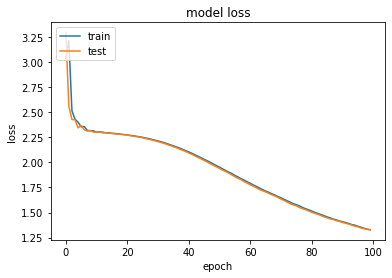

In [31]:
batch_size = 20000
epochs = 100
model.compile(loss='categorical_crossentropy',
              optimizer='adam',
              metrics=['accuracy'])

    
history = model.fit(X_train, y_train,
                    batch_size=batch_size,
                    epochs=epochs,
                    verbose=1,
                    validation_data=(X_test, y_test)
                    )


score = model.evaluate(X_test, y_test, verbose=False)

print()
print ('Test loss:', round(score[0], 3))
print ('Test accuracy:', round(score[1], 3))


plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train', 'test'], loc='upper left')

Observations on  the above model:
1. The model has been created without BatchNormalizations and early stoppings
2. It has been observed by there is a stedy fall in loss and increase in accuracy.
3. The steady fall in  loss and increased accuracy for 100 epochs might mean that the global minima might not have appeared. 

Let's try with higher epocs and early stopping.

In [35]:
model = Sequential()
# model.add(BatchNormalization(input_shape=(1024,)))
model.add(Dense(1024, activation='relu', input_shape=(1024,)))   #First hidden layer of 1024  neurons, each neuron takes input 
                                                               # vector of size 1024



model.add(Dense(num_classes, activation='softmax'))            # Adding a softmax layer for output which contains as many 
                                                               # neurons as the number of classes (10) which is also the 
                                                               # the shape of each output vector ( one hot coded)

                                                               # output layer also uses softmax. This normalizes the values 
                                                               # from the ten output nodes such that: 
                                                               #        all the values are between 0 and 1, and
                                                               #        the sum of all ten values is 1.  
                                                               # prediction is the lable of the node that gets highest fraction, is 
        
        

for l in model.layers:
    print (l.name, l.input_shape,'==>',l.output_shape)
print()
print (model.summary())

dense_10 (None, 1024) ==> (None, 1024)
dense_11 (None, 1024) ==> (None, 10)

Model: "sequential_5"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
dense_10 (Dense)             (None, 1024)              1049600   
_________________________________________________________________
dense_11 (Dense)             (None, 10)                10250     
Total params: 1,059,850
Trainable params: 1,059,850
Non-trainable params: 0
_________________________________________________________________
None


Epoch 1/400
3/3 [==============================] - 0s 74ms/step - loss: 3.6619 - accuracy: 0.1003 - val_loss: 3.2191 - val_accuracy: 0.0972
Epoch 2/400
3/3 [==============================] - 0s 45ms/step - loss: 3.1141 - accuracy: 0.1003 - val_loss: 2.9711 - val_accuracy: 0.1029
Epoch 3/400
3/3 [==============================] - 0s 41ms/step - loss: 2.9732 - accuracy: 0.1011 - val_loss: 2.7347 - val_accuracy: 0.1051
Epoch 4/400
3/3 [==============================] - 0s 45ms/step - loss: 2.7052 - accuracy: 0.1070 - val_loss: 2.5641 - val_accuracy: 0.0958
Epoch 5/400
3/3 [==============================] - 0s 45ms/step - loss: 2.5086 - accuracy: 0.1055 - val_loss: 2.3361 - val_accuracy: 0.1039
Epoch 6/400
3/3 [==============================] - 0s 44ms/step - loss: 2.3308 - accuracy: 0.1022 - val_loss: 2.3781 - val_accuracy: 0.1002
Epoch 7/400
3/3 [==============================] - 0s 44ms/step - loss: 2.3767 - accuracy: 0.0999 - val_loss: 2.3446 - val_accuracy: 0.0996
Epoch 8/400
3/3 [===

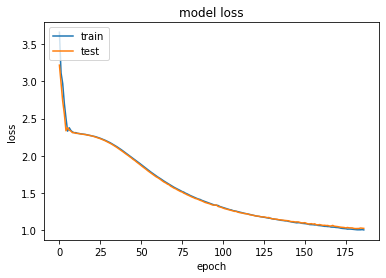

In [36]:
batch_size = 20000
epochs = 400   # Setting up higher epoch in persuit of finding global moinima,
model.compile(loss='categorical_crossentropy',
              optimizer='adam',
              metrics=['accuracy'])

es = EarlyStopping(monitor='val_loss', mode='min', verbose=1, patience=5)   # Set up early stopping to avoid wastage of computing power
                                                                            # Kept patience level to 5 to check for considerable time to get out of local minima if possible
    
history = model.fit(X_train, y_train,
                    batch_size=batch_size,
                    epochs=epochs,
                    verbose=1,
                    callbacks = [es],
                    validation_data=(X_test, y_test)
                    )


score = model.evaluate(X_test, y_test, verbose=False)

print()
print ('Test loss:', round(score[0], 3))
print ('Test accuracy:', round(score[1], 3))


plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train', 'test'], loc='upper left')

Observations
1. With higher epochs we were able to find better global minima
2. The early stop made sure to avoid trying more time and wasting power.
3. The test accuracy is at about 70%

Trying with Batch Normalization technique

# Implement batch normalization for training the neural network

In [37]:
model = Sequential()
model.add(BatchNormalization(input_shape=(1024,))) # Set the batch normalization with input shape 32 x 32
model.add(Dense(1024, activation='relu', input_shape=(1024,)))   #First hidden layer of 1024  neurons, each neuron takes input 
                                                               # vector of size 1024



model.add(Dense(num_classes, activation='softmax'))            # Adding a softmax layer for output which contains as many 
                                                               # neurons as the number of classes (10) which is also the 
                                                               # the shape of each output vector ( one hot coded)

                                                               # output layer also uses softmax. This normalizes the values 
                                                               # from the ten output nodes such that: 
                                                               #        all the values are between 0 and 1, and
                                                               #        the sum of all ten values is 1.  
                                                               # prediction is the lable of the node that gets highest fraction, is 
        
        

for l in model.layers:
    print (l.name, l.input_shape,'==>',l.output_shape)
print()
print (model.summary())

batch_normalization_2 (None, 1024) ==> (None, 1024)
dense_12 (None, 1024) ==> (None, 1024)
dense_13 (None, 1024) ==> (None, 10)

Model: "sequential_6"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
batch_normalization_2 (Batch (None, 1024)              4096      
_________________________________________________________________
dense_12 (Dense)             (None, 1024)              1049600   
_________________________________________________________________
dense_13 (Dense)             (None, 10)                10250     
Total params: 1,063,946
Trainable params: 1,061,898
Non-trainable params: 2,048
_________________________________________________________________
None


Epoch 1/400
3/3 [==============================] - 0s 74ms/step - loss: 3.5780 - accuracy: 0.1055 - val_loss: 3.5423 - val_accuracy: 0.1142
Epoch 2/400
3/3 [==============================] - 0s 49ms/step - loss: 3.8291 - accuracy: 0.1332 - val_loss: 2.9318 - val_accuracy: 0.1007
Epoch 3/400
3/3 [==============================] - 0s 51ms/step - loss: 3.3568 - accuracy: 0.1629 - val_loss: 2.7811 - val_accuracy: 0.1013
Epoch 4/400
3/3 [==============================] - 0s 46ms/step - loss: 2.6777 - accuracy: 0.2166 - val_loss: 2.6599 - val_accuracy: 0.1104
Epoch 5/400
3/3 [==============================] - 0s 51ms/step - loss: 2.5269 - accuracy: 0.2318 - val_loss: 2.4155 - val_accuracy: 0.1362
Epoch 6/400
3/3 [==============================] - 0s 44ms/step - loss: 2.1126 - accuracy: 0.3205 - val_loss: 2.3423 - val_accuracy: 0.1037
Epoch 7/400
3/3 [==============================] - 0s 45ms/step - loss: 2.0754 - accuracy: 0.3344 - val_loss: 2.3656 - val_accuracy: 0.1459
Epoch 8/400
3/3 [===

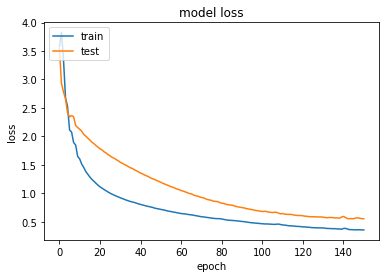

In [38]:
batch_size = 20000
epochs = 400   # Setting up higher epoch in persuit of finding global moinima,
model.compile(loss='categorical_crossentropy',
              optimizer='adam',
              metrics=['accuracy'])

es = EarlyStopping(monitor='val_loss', mode='min', verbose=1, patience=5)   # Set up early stopping to avoid wastage of computing power
                                                                            # Kept patience level to 5 to check for considerable time to get out of local minima if possible
    
history = model.fit(X_train, y_train,
                    batch_size=batch_size,
                    epochs=epochs,
                    verbose=1,
                    callbacks = [es],
                    validation_data=(X_test, y_test)
                    )


score = model.evaluate(X_test, y_test, verbose=False)

print()
print ('Test loss:', round(score[0], 3))
print ('Test accuracy:', round(score[1], 3))


plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train', 'test'], loc='upper left')

Observations
1. The BatchNormalization performs much better compared without normalization.
2. The loss functions is pretty step as compared to without normalization. 
3. The accuracy reaches to highest level pity soon.

Taking the above model and going ahead with prediction.

# Print the classification accuracy metrics (Print Both Classification report and Confusion Matrix )

In [39]:
Y_pred_cls = model.predict_classes(X_test, batch_size=200, verbose=0)
y_true = np.argmax(y_test, axis=1) 
print('Accuracy Model1 (Dropout): '+ str(model.evaluate(X_test,y_test)[1]))

Instructions for updating:
Please use instead:* `np.argmax(model.predict(x), axis=-1)`,   if your model does multi-class classification   (e.g. if it uses a `softmax` last-layer activation).* `(model.predict(x) > 0.5).astype("int32")`,   if your model does binary classification   (e.g. if it uses a `sigmoid` last-layer activation).
563/563 [==============================] - 1s 2ms/step - loss: 0.5530 - accuracy: 0.8488
Accuracy Model1 (Dropout): 0.8488333225250244


Model accuracy is 84.88 %

In [40]:
print(classification_report(y_true, Y_pred_cls)) # Print the classification report

              precision    recall  f1-score   support

           0       0.87      0.89      0.88      1814
           1       0.84      0.86      0.85      1828
           2       0.87      0.85      0.86      1803
           3       0.81      0.79      0.80      1719
           4       0.87      0.87      0.87      1812
           5       0.80      0.86      0.83      1768
           6       0.86      0.83      0.85      1832
           7       0.89      0.88      0.88      1808
           8       0.83      0.81      0.82      1812
           9       0.83      0.84      0.84      1804

    accuracy                           0.85     18000
   macro avg       0.85      0.85      0.85     18000
weighted avg       0.85      0.85      0.85     18000



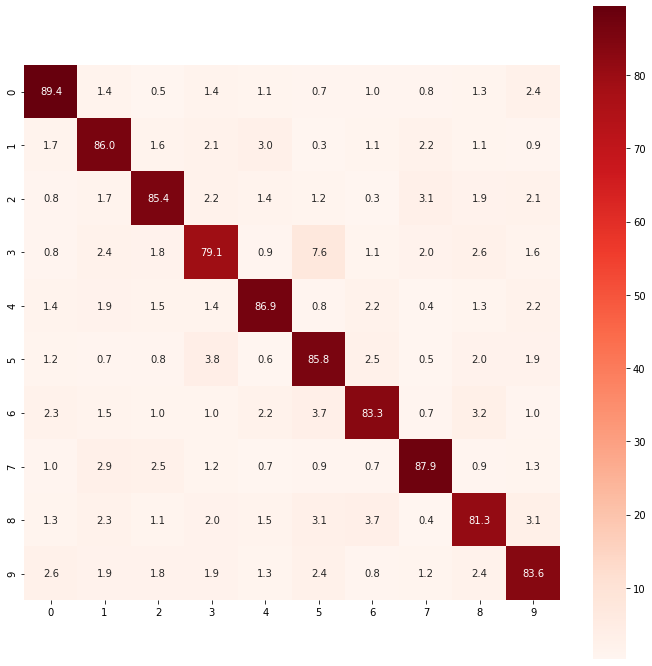

In [42]:
conf = confusion_matrix(y_true, Y_pred_cls)
plt.figure(figsize=(12, 12))
# Normalize the confusion matrix
conf = conf.astype('float') / conf.sum(axis=1)[:, np.newaxis] * 100.0
# Visualize the confusion matrix
sn.heatmap(conf, annot=True, cmap='Reds', fmt='.1f', square=True);

Observations
Based on both the classification and confusion matrix we can observer that: 
1. The model is able to predict value of 0 followed by 7 quite well
2. The model has lowest predictability for 3 and 8 which is clearly evident as 3 and 8 resemble closely in texture.